**bold text**#  CLOUD INFRASTRUCTURE CLUSTERING PROJECT
## Accenture AI Labs - Resource Optimization

This notebook performs K-Means clustering on cloud server configurations to group similar systems for informed optimization decisions.

---

### 📋 What This Notebook Does:
1. Loads cloud infrastructure data
2. Cleans and preprocesses the data
3. Analyzes feature correlations
4. Applies K-Means clustering
5. Visualizes clusters using PCA and t-SNE
6. Interprets cluster characteristics
7. Generates professional reports

---



 Upload Dataset



In [ ]:
from google.colab import files
import os

print("📁 Please upload your cloud_infrastructure_data.csv file:")
uploaded = files.upload()

if 'cloud_infrastructure_data.csv' in uploaded:
    print("\n✅ File uploaded successfully!")
else:
    print("\n⚠️ Please make sure the file is named: cloud_infrastructure_data.csv")

📁 Please upload your cloud_infrastructure_data.csv file:


Saving cloud_infrastructure_data.csv to cloud_infrastructure_data.csv

✅ File uploaded successfully!


 Import Required Libraries

In [ ]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


 Load and Explore Data

In [ ]:

df = pd.read_csv('cloud_infrastructure_data.csv')

print("="*60)
print("DATA LOADED SUCCESSFULLY")
print("="*60)
print(f"\nDataset Shape: {df.shape}")
print(f"   - Total Servers: {len(df)}")
print(f"   - Features: {len(df.columns) - 1}\n")

print("\n📋 First 5 rows:")
df.head()

DATA LOADED SUCCESSFULLY

📊 Dataset Shape: (200, 6)
   - Total Servers: 200
   - Features: 5


📋 First 5 rows:


,Server_ID,Processing_Power,Memory,Storage_Speed,Network_Bandwidth,Energy_Consumption
0,SERVER_0096,2.24,NaN,1000,500,99.1
1,SERVER_0016,3.18,NaN,2000,1000,159.4
2,SERVER_0031,3.61,64.0,1000,1000,194.5
3,SERVER_0159,1.85,16.0,250,500,53.8
4,SERVER_0129,2.96,32.0,500,500,134.3


In [ ]:

print("🔍 Dataset Information:")
print(df.info())

print("\n📈 Statistical Summary:")
df.describe()

🔍 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Server_ID           200 non-null    object 
 1   Processing_Power    200 non-null    float64
 2   Memory              190 non-null    float64
 3   Storage_Speed       200 non-null    int64  
 4   Network_Bandwidth   200 non-null    int64  
 5   Energy_Consumption  190 non-null    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 9.5+ KB
None

📈 Statistical Summary:


,Processing_Power,Memory,Storage_Speed,Network_Bandwidth,Energy_Consumption
count,200.000000,190.000000,200.000000,200.000000,190.000000
mean,2.577050,40.210526,840.000000,594.000000,112.608421
std,0.720354,37.445945,543.947973,298.343837,43.638452
min,1.510000,8.000000,250.000000,100.000000,51.100000
25%,1.947500,16.000000,500.000000,500.000000,72.400000
50%,2.570000,32.000000,1000.000000,500.000000,109.850000
75%,3.145000,64.000000,1000.000000,1000.000000,147.050000
max,3.970000,128.000000,2000.000000,1000.000000,199.100000


 Data Cleaning

🕵️ Missing Values Check:
Server_ID              0
Processing_Power       0
Memory                10
Storage_Speed          0
Network_Bandwidth      0
Energy_Consumption    10
dtype: int64

Total missing values: 20


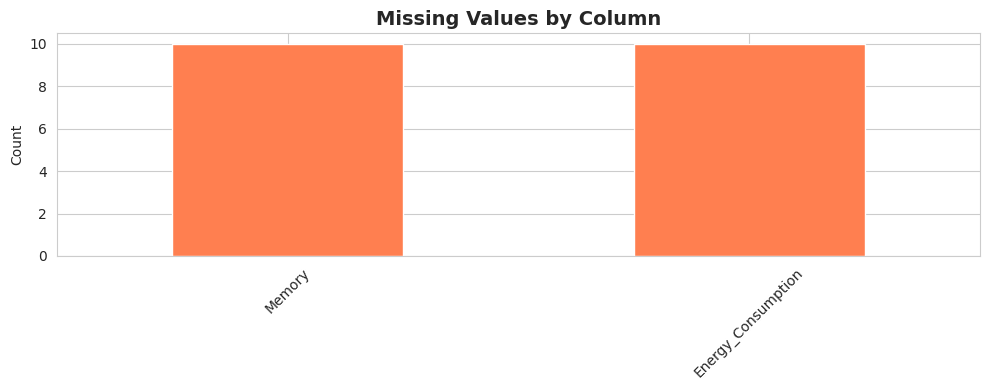

In [ ]:

print(" Missing Values Check:")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")


if missing.sum() > 0:
    plt.figure(figsize=(10, 4))
    missing[missing > 0].plot(kind='bar', color='coral')
    plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:

numeric_columns = ['Processing_Power', 'Memory', 'Storage_Speed',
                   'Network_Bandwidth', 'Energy_Consumption']

print("🛠️ Handling Missing Values...\n")
for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        mean_value = df[col].mean()
        df[col].fillna(mean_value, inplace=True)
        print(f" Filled {col} with mean: {mean_value:.2f}")
print(f"\n Missing values after cleaning: {df.isnull().sum().sum()}")

🛠️ Handling Missing Values...

✅ Filled Memory with mean: 40.21
✅ Filled Energy_Consumption with mean: 112.61

✅ Missing values after cleaning: 0


 Feature Correlation Analysis

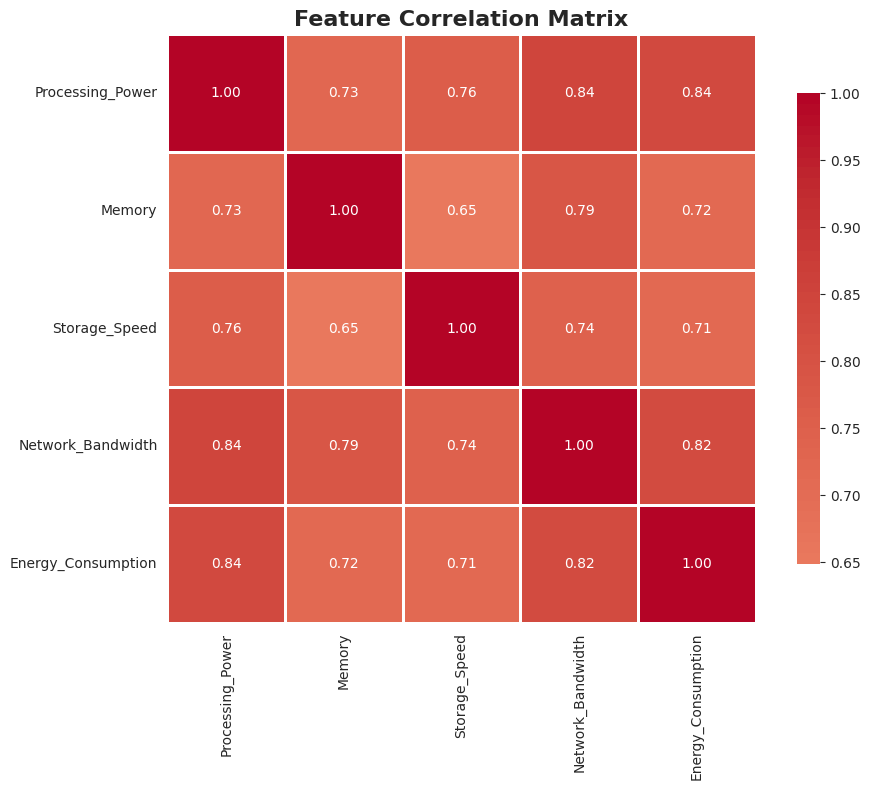


💡 Interpretation:
   - Values close to 1: Strong positive correlation
   - Values close to -1: Strong negative correlation
   - Values close to 0: No correlation


In [ ]:

features = ['Processing_Power', 'Memory', 'Storage_Speed',
            'Network_Bandwidth', 'Energy_Consumption']
X = df[features]


correlation_matrix = X.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f', cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   - Values close to 1: Strong positive correlation")
print("   - Values close to -1: Strong negative correlation")
print("   - Values close to 0: No correlation")

 Feature Scaling (CRITICAL!)



In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(" Features scaled using StandardScaler")
print("   All features now have mean=0 and std=1\n")


print("Example - Memory feature:")
print(f"   Before scaling: {X['Memory'].min():.1f} to {X['Memory'].max():.1f}")
print(f"   After scaling:  {X_scaled[:, 1].min():.2f} to {X_scaled[:, 1].max():.2f}")

 Features scaled using StandardScaler
   All features now have mean=0 and std=1

Example - Memory feature:
   Before scaling: 8.0 to 128.0
   After scaling:  -0.88 to 2.41


 Finding Optimal Number of Clusters (K)



In [ ]:

K_range = range(2, 11)
inertias = []
silhouette_scores = []

print("🔍 Testing different values of K...\n")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette Score={score:.3f}")


optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nOPTIMAL K = {optimal_k} (highest silhouette score: {max(silhouette_scores):.3f})")

🔍 Testing different values of K...

K=2: Inertia=338.55, Silhouette Score=0.592
K=3: Inertia=214.50, Silhouette Score=0.485
K=4: Inertia=163.65, Silhouette Score=0.470
K=5: Inertia=135.43, Silhouette Score=0.486
K=6: Inertia=107.78, Silhouette Score=0.490
K=7: Inertia=87.98, Silhouette Score=0.522
K=8: Inertia=71.21, Silhouette Score=0.485
K=9: Inertia=65.07, Silhouette Score=0.477
K=10: Inertia=59.09, Silhouette Score=0.463

OPTIMAL K = 2 (highest silhouette score: 0.592)


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inertia plot
axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='#2E86AB')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)


axes[1].plot(K_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='#A23B72')
axes[1].axhline(y=max(silhouette_scores), color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score Analysis', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

 Apply K-Means Clustering

In [ ]:

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = cluster_labels

print("Clustering Complete!\n")
print(f" Cluster Distribution:")
cluster_counts = df['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   Cluster {cluster_id}: {count} servers ({percentage:.1f}%)")

Clustering Complete!

 Cluster Distribution:
   Cluster 0: 60 servers (30.0%)
   Cluster 1: 140 servers (70.0%)


 Cluster Analysis & Interpretation

In [ ]:
print("="*80)
print("CLUSTER CHARACTERISTICS")
print("="*80)

for cluster_id in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_id]
    cluster_size = len(cluster_data)

    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*80}")
    print(f"Size: {cluster_size} servers ({cluster_size/len(df)*100:.1f}%)\n")
    print("Average Characteristics:")

    for feature in features:
        avg = cluster_data[feature].mean()
        print(f"   • {feature}: {avg:.2f}")

    # Interpretation
    avg_power = cluster_data['Processing_Power'].mean()
    avg_memory = cluster_data['Memory'].mean()
    avg_energy = cluster_data['Energy_Consumption'].mean()

    print(f"\n Interpretation:")
    if avg_power > 3.0 and avg_memory > 50:
        print(f"    HIGH-PERFORMANCE CLUSTER")
        print(f"   - Use for: Databases, analytics, heavy workloads")
        print(f"   - Energy: High ({avg_energy:.1f}W)")
    elif avg_power < 2.0 and avg_memory < 20:
        print(f"    LOW-END/EFFICIENT CLUSTER")
        print(f"   - Use for: Web servers, testing, simple tasks")
        print(f"   - Energy: Low ({avg_energy:.1f}W)")
    else:
        print(f"    MID-RANGE/BALANCED CLUSTER")
        print(f"   - Use for: General applications, development")
        print(f"   - Energy: Moderate ({avg_energy:.1f}W)")

CLUSTER CHARACTERISTICS

CLUSTER 0
Size: 60 servers (30.0%)

Average Characteristics:
   • Processing_Power: 3.47
   • Memory: 86.95
   • Storage_Speed: 1450.00
   • Network_Bandwidth: 1000.00
   • Energy_Consumption: 162.93

💡 Interpretation:
    HIGH-PERFORMANCE CLUSTER
   - Use for: Databases, analytics, heavy workloads
   - Energy: High (162.9W)

CLUSTER 1
Size: 140 servers (70.0%)

Average Characteristics:
   • Processing_Power: 2.20
   • Memory: 20.18
   • Storage_Speed: 578.57
   • Network_Bandwidth: 420.00
   • Energy_Consumption: 91.04

💡 Interpretation:
    MID-RANGE/BALANCED CLUSTER
   - Use for: General applications, development
   - Energy: Moderate (91.0W)


In [ ]:

cluster_summary = df.groupby('Cluster')[features].mean().round(2)
cluster_summary['Server_Count'] = df.groupby('Cluster').size()

print("\n Cluster Summary Table:")
cluster_summary


 Cluster Summary Table:


,Processing_Power,Memory,Storage_Speed,Network_Bandwidth,Energy_Consumption,Server_Count
Cluster,,,,,,
0,3.47,86.95,1450.00,1000.0,162.93,60
1,2.20,20.18,578.57,420.0,91.04,140


Cluster Visualization - PCA



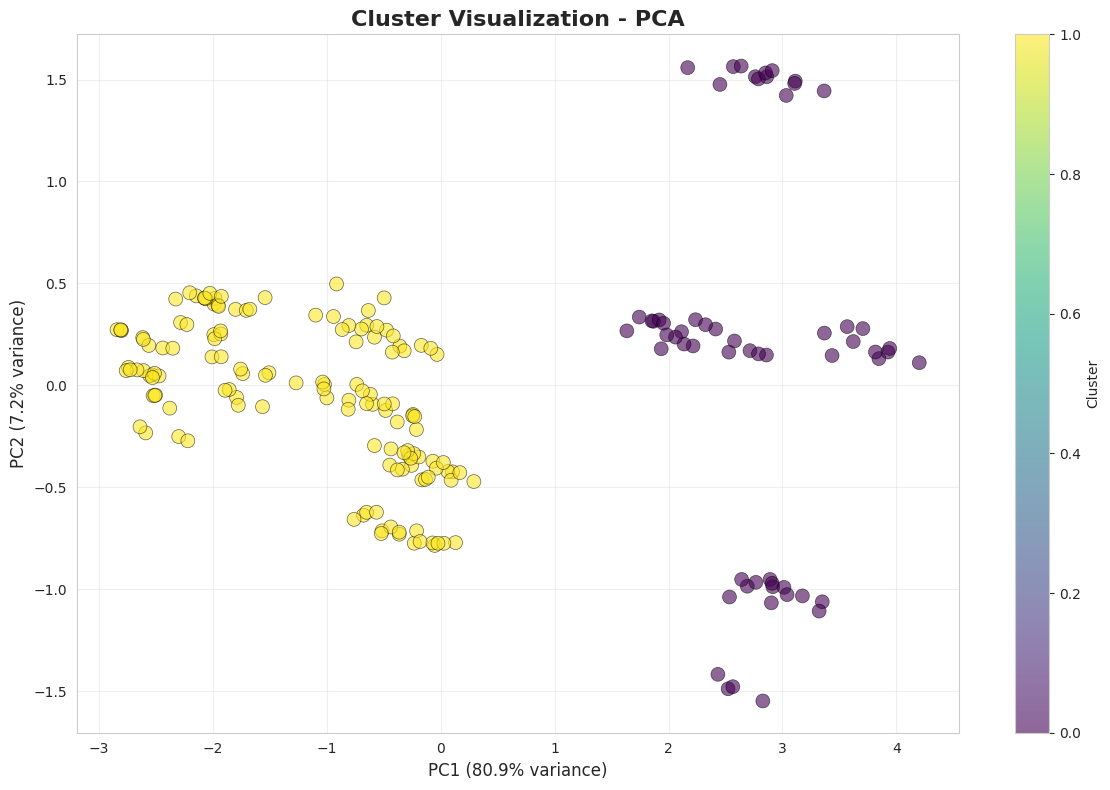


 PCA explains 88.1% of total variance


In [ ]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'],
                     cmap='viridis', s=100, alpha=0.6,
                     edgecolors='black', linewidth=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Cluster Visualization - PCA', fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n PCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of total variance")

Cluster Visualization - t-SNE



⏳ Running t-SNE (this may take 30-60 seconds)...


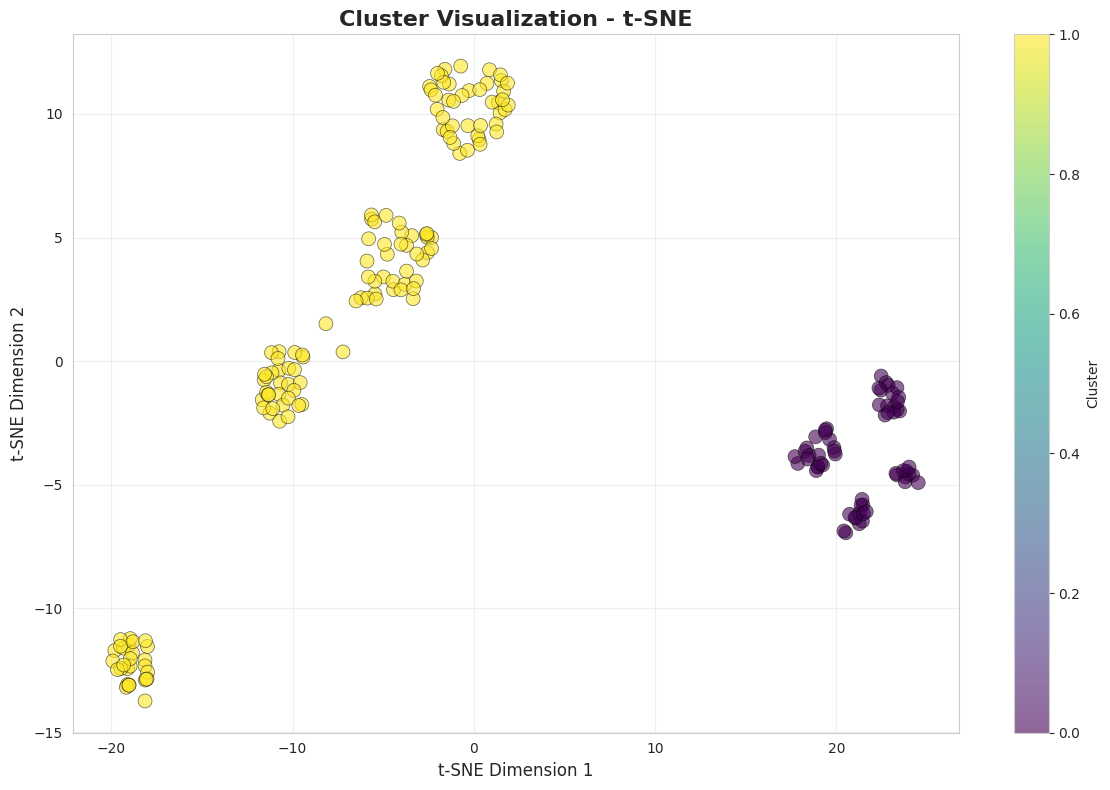

 t-SNE visualization complete!


In [ ]:

print("⏳ Running t-SNE (this may take 30-60 seconds)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)


df['TSNE1'] = X_tsne[:, 0]
df['TSNE2'] = X_tsne[:, 1]


plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['TSNE1'], df['TSNE2'], c=df['Cluster'],
                     cmap='viridis', s=100, alpha=0.6,
                     edgecolors='black', linewidth=0.5)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('Cluster Visualization - t-SNE', fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(" t-SNE visualization complete!")

 Feature Distributions by Cluster

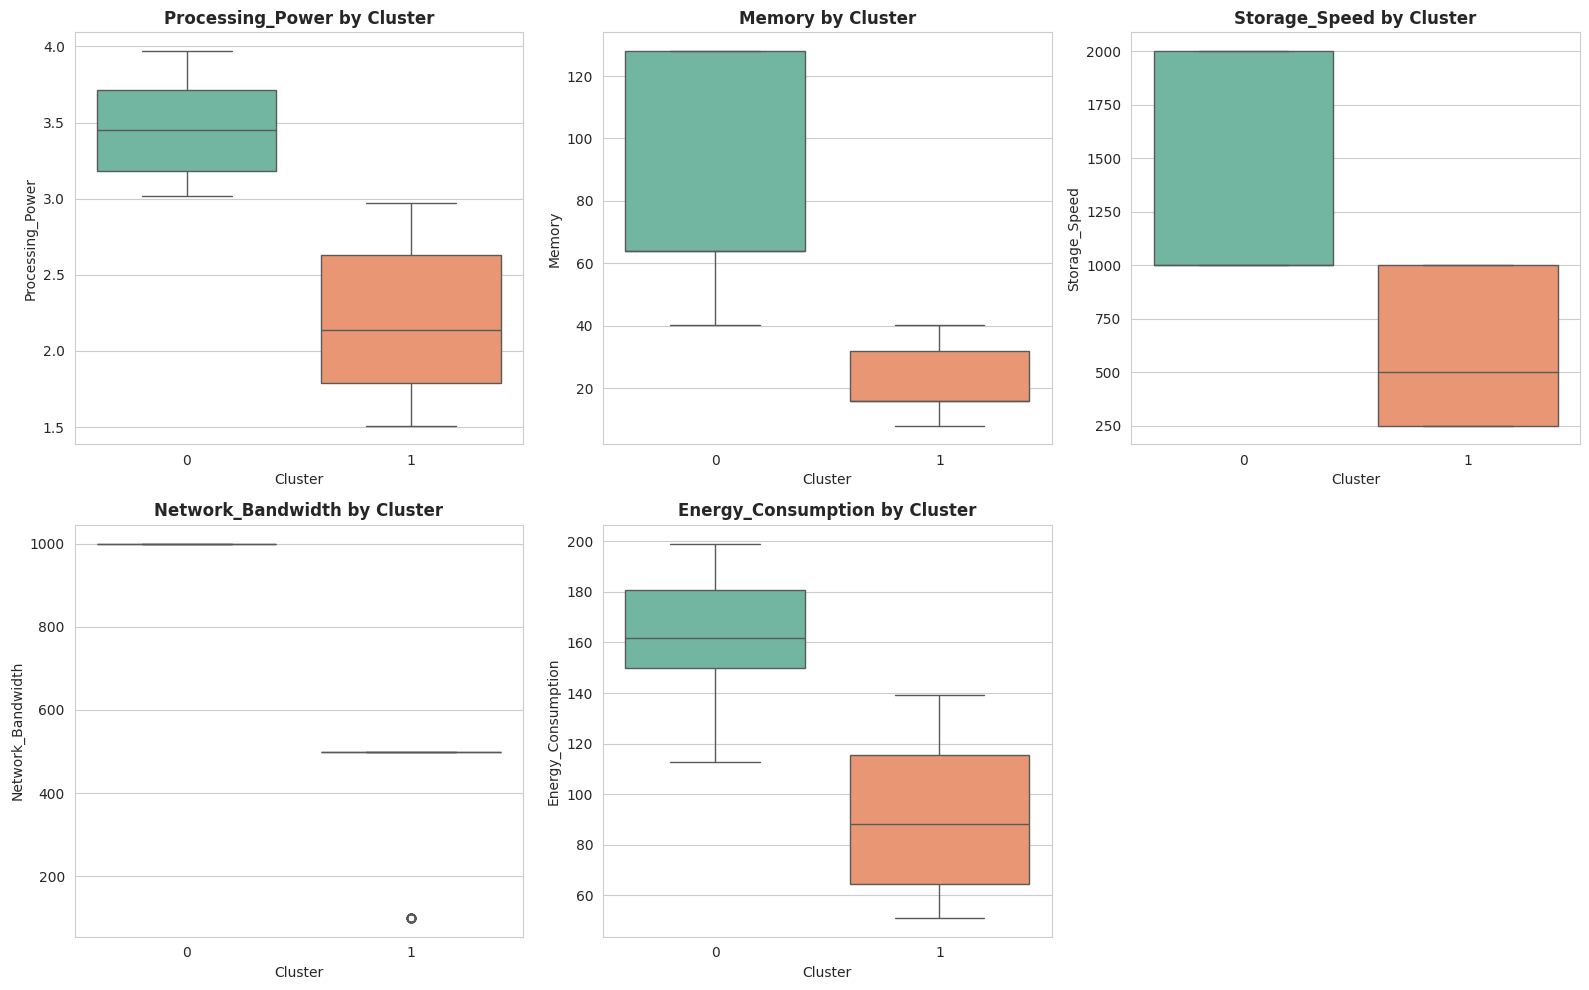

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(features):
    sns.boxplot(data=df, x='Cluster', y=feature, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{feature} by Cluster', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Cluster', fontsize=10)
    axes[idx].set_ylabel(feature, fontsize=10)


fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


Save Results

In [ ]:

df.to_csv('clustered_cloud_data.csv', index=False)
print("Clustered data saved: clustered_cloud_data.csv")


cluster_summary.to_csv('cluster_analysis.csv')
print(" Cluster analysis saved: cluster_analysis.csv")

print("\n Download your results:")
files.download('clustered_cloud_data.csv')
files.download('cluster_analysis.csv')

Clustered data saved: clustered_cloud_data.csv
 Cluster analysis saved: cluster_analysis.csv

 Download your results:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



 Summary:
-  Analyzed 200 cloud servers
-  Applied K-Means clustering
-  Identified distinct server groups
- Created professional visualizations
-  Generated actionable insights